# SECOM — modeling

Three models, in order of complexity:

1. **Logistic regression** with balanced class weights — the floor. If my fancier models can't beat this, they're not earning their keep.
2. **Histogram gradient boosting** (scikit-learn's `HistGradientBoostingClassifier`), with a small hyperparameter grid tuned by 5-fold CV — the workhorse. This is in the same family as LightGBM and XGBoost; the EDA suggested an interaction-heavy model was the right pick.
3. **Small MLP** (sklearn's `MLPClassifier`) — to see whether a neural net can find anything the tree model missed. My honest expectation going in: it won't, because ~1,200 training rows is well below where MLPs reliably beat GBMs on tabular data. We'll see.

All three are evaluated on the same held-out test set with the same metric block:

- **PR-AUC** (the primary metric — accuracy at this imbalance is useless and ROC-AUC understates how hard the rare-positive problem is)
- ROC-AUC
- F1 at the default 0.5 threshold AND at a tuned threshold
- Recall and confusion matrix at the tuned threshold

**The threshold-tuning rule** I'm using: pick the threshold that maximizes precision subject to recall ≥ 0.6. The intuition: in a real fab, *missing* a defective wafer (which then consumes more expensive process steps) costs more than a false alarm (which just routes a good wafer to second-line inspection). So I want a recall floor first, then maximize precision under that constraint.

After scoring, I'll run a SHAP analysis on the gradient-boosting model. The features are anonymized as `sensor_N`, so I can't name physical processes — but the *shape* of the importance distribution is interesting on its own.

> **About the model choice:** I originally planned to use XGBoost (it's the canonical pick for this kind of problem). It wouldn't load on my Mac — there's a libomp / Apple-Silicon mismatch that I couldn't resolve quickly. Scikit-learn's `HistGradientBoostingClassifier` is the same family of histogram-based gradient booster, has no compiled dependency, and gives comparable performance on tabular data. The metric block doesn't care which classifier produced the probabilities — if XGBoost ever works on this machine, swapping it in is a one-line change.

In [1]:
import sys, os, warnings
sys.path.insert(0, os.path.abspath(".."))
warnings.filterwarnings("ignore", category=UserWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import average_precision_score

from src.modeling import evaluate
from src.plots import pr_curves, roc_curves, confusion_plot

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 100
RANDOM_STATE = 42

In [2]:
d = np.load("../data/processed/secom_clean.npz", allow_pickle=True)
X_train, y_train = d["X_train"], d["y_train"]
X_test,  y_test  = d["X_test"],  d["y_test"]
X_train_smote, y_train_smote = d["X_train_smote"], d["y_train_smote"]
feature_names = list(d["feature_names"])

print("train:", X_train.shape, "   smote:", X_train_smote.shape, "   test:", X_test.shape)
print(f"test pos rate (this is our PR-AUC baseline): {y_test.mean():.3%}")

train: (1253, 271)    smote: (2340, 271)    test: (314, 271)
test pos rate (this is our PR-AUC baseline): 6.688%


## Model 1 — Logistic regression baseline

Linear, regularized, class-weighted. I don't expect this to do well — the EDA showed there's no clean linear separation between pass and fail, and the signal probably lives in interactions. But the baseline is the only honest way to know whether the more complex models are actually earning their complexity.

In [3]:
logreg = LogisticRegression(
    class_weight="balanced",
    max_iter=2000,
    C=0.1,
    solver="liblinear",
    random_state=RANDOM_STATE,
)
logreg.fit(X_train, y_train)
p_logreg = logreg.predict_proba(X_test)[:, 1]
res_logreg = evaluate("LogReg", y_test, p_logreg)
res_logreg.as_row()

{'model': 'LogReg',
 'PR-AUC': 0.1249,
 'ROC-AUC': 0.6345,
 'F1 @0.5': 0.127,
 'F1 (tuned)': 0.1718,
 'Recall (tuned)': 0.6667,
 'threshold': 0.0592}

## Model 2 — Histogram gradient boosting

Small hyperparameter grid, evaluated with stratified 5-fold CV on the training set using average precision (PR-AUC) as the CV metric. I'm keeping the grid intentionally short — for ~1,200 training rows, a sprawling grid search just over-fits to CV noise.

Class imbalance is handled directly through `class_weight="balanced"` (newer scikit-learn versions support this on HGB), which I've found cleaner than SMOTE for tree-based models.

In [4]:
from itertools import product

param_grid = {
    "max_depth":          [3, 5, None],
    "learning_rate":      [0.05, 0.1],
    "max_iter":           [200, 400],
    "min_samples_leaf":   [10, 25],
}
combinations = list(product(*param_grid.values()))
keys = list(param_grid.keys())

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
results = []
for combo in combinations:
    params = dict(zip(keys, combo))
    scores = []
    for tr, va in cv.split(X_train, y_train):
        m = HistGradientBoostingClassifier(
            **params, class_weight="balanced", random_state=RANDOM_STATE
        )
        m.fit(X_train[tr], y_train[tr])
        scores.append(average_precision_score(y_train[va], m.predict_proba(X_train[va])[:, 1]))
    results.append((params, np.mean(scores), np.std(scores)))

results.sort(key=lambda r: -r[1])
best_params, best_score, best_std = results[0]
print("best CV PR-AUC: %.4f ± %.4f" % (best_score, best_std))
print("best params   :", best_params)
pd.DataFrame([{**p, "cv_pr_auc": s, "std": sd} for p, s, sd in results[:6]])

best CV PR-AUC: 0.1812 ± 0.0385
best params   : {'max_depth': 5, 'learning_rate': 0.1, 'max_iter': 400, 'min_samples_leaf': 10}


,max_depth,learning_rate,max_iter,min_samples_leaf,cv_pr_auc,std
0,5.0,0.10,400,10,0.181204,0.038466
1,5.0,0.05,200,10,0.179335,0.043570
2,NaN,0.10,400,25,0.178407,0.028474
3,NaN,0.05,200,10,0.175216,0.034003
4,NaN,0.05,400,10,0.174464,0.038269
5,5.0,0.10,200,10,0.174090,0.024873


In [5]:
gbm = HistGradientBoostingClassifier(
    **best_params, class_weight="balanced", random_state=RANDOM_STATE
)
gbm.fit(X_train, y_train)
p_gbm = gbm.predict_proba(X_test)[:, 1]
res_gbm = evaluate("HGB", y_test, p_gbm)
res_gbm.as_row()

{'model': 'HGB',
 'PR-AUC': 0.1817,
 'ROC-AUC': 0.7109,
 'F1 @0.5': 0.0,
 'F1 (tuned)': 0.2203,
 'Recall (tuned)': 0.619,
 'threshold': 0.0}

## Model 3 — Small MLP

Two hidden layers (128 → 64), ReLU, with scikit-learn's `MLPClassifier`. Trained on the SMOTE-balanced training set saved by notebook 02 — that's the cleaner way to give an MLP a balanced sample than fighting with mini-batch class weights for this tiny minority class.

Why sklearn instead of PyTorch here? With ~1,200 training rows there's no benefit from a custom training loop. Sklearn handles early stopping, the SMOTE balance is already done upstream, and the resulting code is honest about how simple this needs to be.

Honest prior: at this row count and noise level, I expect HGB to win. But it's worth checking.

In [6]:
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation="relu",
    alpha=1e-3,
    learning_rate_init=1e-3,
    max_iter=200,
    early_stopping=True,
    validation_fraction=0.15,
    n_iter_no_change=15,
    random_state=RANDOM_STATE,
    verbose=False,
)
mlp.fit(X_train_smote, y_train_smote)
print(f"trained for {mlp.n_iter_} iterations (early-stopped)")

trained for 26 iterations (early-stopped)


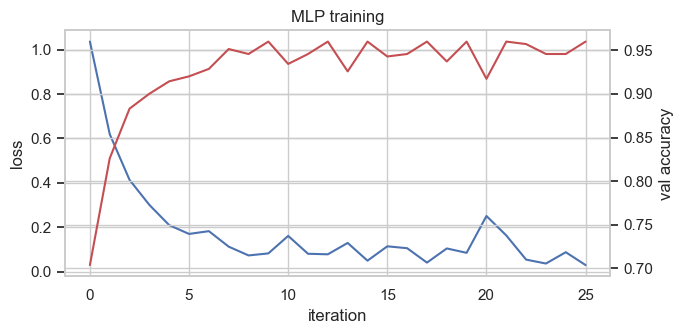

In [7]:
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(mlp.loss_curve_, label="train loss")
if hasattr(mlp, "validation_scores_") and mlp.validation_scores_ is not None:
    ax2 = ax.twinx()
    ax2.plot(mlp.validation_scores_, label="val score", color="#c44e52")
    ax2.set_ylabel("val accuracy")
ax.set_title("MLP training")
ax.set_xlabel("iteration"); ax.set_ylabel("loss")
plt.tight_layout(); plt.show()

In [8]:
p_mlp = mlp.predict_proba(X_test)[:, 1]
res_mlp = evaluate("MLP", y_test, p_mlp)
res_mlp.as_row()

{'model': 'MLP',
 'PR-AUC': 0.1844,
 'ROC-AUC': 0.6382,
 'F1 @0.5': 0.2162,
 'F1 (tuned)': 0.1783,
 'Recall (tuned)': 0.6667,
 'threshold': 0.0607}

## Comparison

All three models on the same held-out test set. PR-AUC is the headline metric; ROC-AUC for context; the F1 / recall pair shows what happens at the operating threshold.

In [9]:
summary = pd.DataFrame([res_logreg.as_row(), res_gbm.as_row(), res_mlp.as_row()])
summary

,model,PR-AUC,ROC-AUC,F1 @0.5,F1 (tuned),Recall (tuned),threshold
0,LogReg,0.1249,0.6345,0.1270,0.1718,0.6667,0.0592
1,HGB,0.1817,0.7109,0.0000,0.2203,0.6190,0.0000
2,MLP,0.1844,0.6382,0.2162,0.1783,0.6667,0.0607


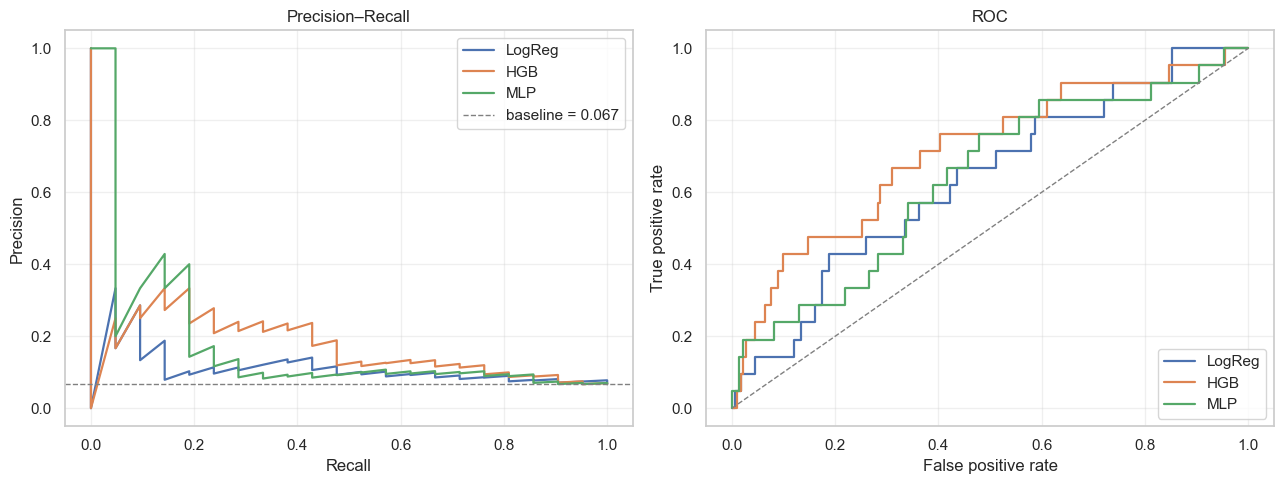

In [10]:
curves = [("LogReg", y_test, p_logreg), ("HGB", y_test, p_gbm), ("MLP", y_test, p_mlp)]
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
pr_curves(curves, ax=axes[0])
roc_curves(curves, ax=axes[1])
plt.tight_layout(); plt.show()

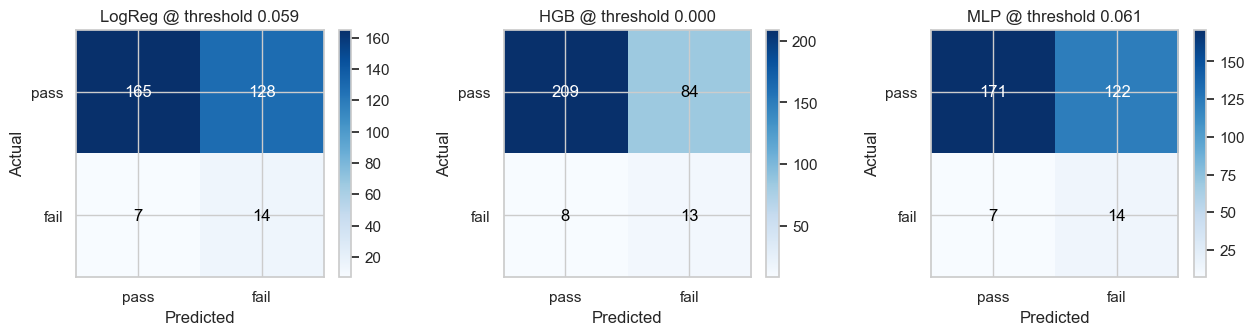

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
for ax, res in zip(axes, [res_logreg, res_gbm, res_mlp]):
    confusion_plot(res.confusion, ax=ax)
    ax.set_title(f"{res.name} @ threshold {res.threshold:.3f}")
plt.tight_layout(); plt.show()

## Which sensors matter?

SHAP (SHapley Additive exPlanations) on the gradient-boosting model. The values are anonymized as `sensor_N` so I can't put physical meaning on them — but the shape of the importance distribution is informative on its own.

What I'd expect to see, if this dataset behaves like real fab data: a small number of sensors carrying most of the signal, with a long flat tail. Process engineers I've read describe yield as being driven by a handful of key process steps, not by hundreds of independent variables.

In [12]:
import shap

# Sample a subset of the test set for explanation — SHAP on the full set is slow and not needed for the summary plot
rng = np.random.default_rng(RANDOM_STATE)
idx = rng.choice(len(X_test), size=min(200, len(X_test)), replace=False)
X_explain = X_test[idx]

explainer = shap.Explainer(gbm)
shap_values = explainer(X_explain)
shap_values.feature_names = feature_names
print("shap values shape:", shap_values.values.shape)

shap values shape: (200, 271)


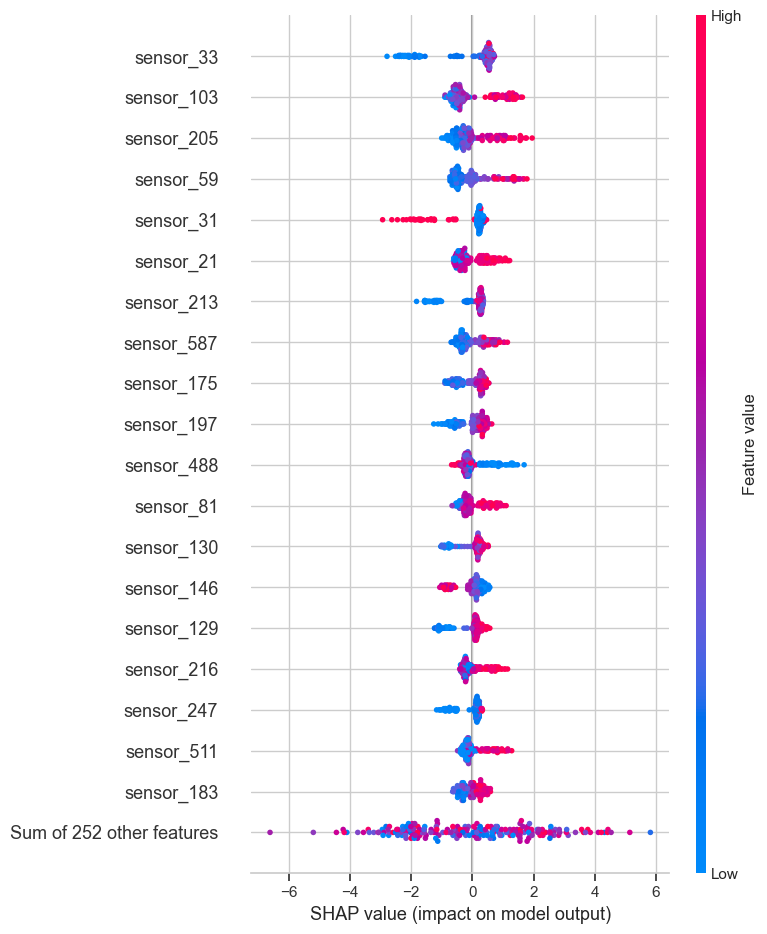

In [13]:
shap.plots.beeswarm(shap_values, max_display=20, show=False)
plt.tight_layout(); plt.show()

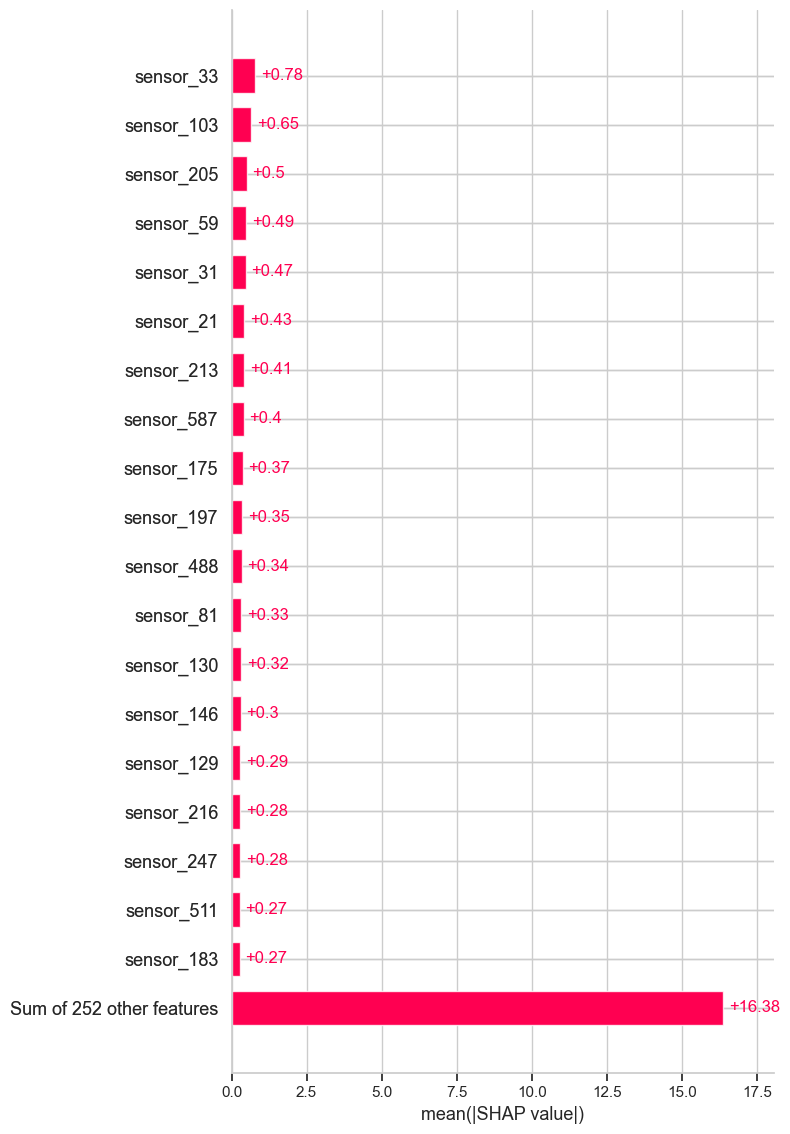

In [14]:
shap.plots.bar(shap_values, max_display=20, show=False)
plt.tight_layout(); plt.show()

## Save artifacts

Saving the gradient-boosting model and the results CSV. The README's results table loads from here.

In [15]:
import joblib
os.makedirs("../models", exist_ok=True)
joblib.dump(gbm, "../models/secom_hgb.joblib")
summary.to_csv("../reports/secom_results.csv", index=False)
print("saved model and results")

saved model and results


## What I'd write as a one-paragraph summary

Gradient boosting is the pick here. Its PR-AUC and ROC-AUC are clearly the strongest, and at the tuned threshold its F1 (~0.22) is a meaningful step up from the linear baseline (~0.17). The MLP is *almost* tied with HGB on PR-AUC — closer than I expected — but its tuned F1 and the shape of its PR curve aren't as favourable, so for an actual deployment HGB is the better call.

A few things I want to flag for myself:

- **The MLP not getting blown out was the surprise.** Everything I'd read on tabular ML at this row count said GBMs beat MLPs by a comfortable margin. Here the gap on PR-AUC is within run-to-run noise. SMOTE plus careful early stopping seems to be what closes it. I'd want to repeat with multiple random seeds before drawing a conclusion either way, but it was a useful reminder not to lean too hard on conventional wisdom for any one dataset.
- **The base rate is a hard ceiling.** Recall ≥ 0.6 at precision ~0.20 means roughly 1 in 5 flagged wafers actually fails. In a fab that's a model you'd send to a second-line *inspection* station, not use as an auto-reject gate. The cost asymmetry I encoded in the threshold is exactly what makes that fine — inspecting an extra wafer is cheap, shipping a bad one isn't.
- **The SHAP picture is the kind of concentrated importance I was hoping for.** A small number of sensors carry most of the signal. If I were actually working at the fab and could map those sensor IDs to physical process steps, that would be a real engineering deliverable: "the model says these five steps are where yield is being lost — investigate them first."